In [1]:
# Import libries
import numpy as np
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt


current_directory = os.getcwd()
pd.set_option("display.max_columns", None)

print("Current Directory:", current_directory)

Current Directory: /mnt/NAS3/home/jiwon/ECTRES/python


In [2]:
#         .map{ row-> tuple(  row.aa_barcode,
#                             row.patient_barcode,
#                             row.project,
#                             row.tm_object_id,
#                             row.nm_object_id,
#                             row.cp_output_dir,
#                             row.action ) }

## aaSuite_germline_ss

In [36]:
# manifest=pd.read_csv('../manifest/ECTRES_clones_nf_dna_fastqs_20260303.csv')
# manifest["sample_id"] = manifest["sample_legacy_id"].fillna("parental")
# sample_mapping = manifest[['aliquot_barcode','source_barcode','sample_barcode','patient_barcode','sample_id']].drop_duplicates()
# sample_mapping.head()


,aliquot_barcode,source_barcode,sample_barcode,patient_barcode,sample_id
0,ECTRES-ECGI1-0001-TPX-A01-WGS-6DM349,ECGI1,ECTRES-ECGI1-0001-TPX-A01,ECTRES-ECGI1-0001,EG_1
2,ECTRES-ECGI1-0001-TPX-A10-WGS-3SW949,ECGI1,ECTRES-ECGI1-0001-TPX-A10,ECTRES-ECGI1-0001,EG_10
3,ECTRES-ECGI1-0001-TPX-A11-WGS-9HJ669,ECGI1,ECTRES-ECGI1-0001-TPX-A11,ECTRES-ECGI1-0001,EG_11
4,ECTRES-ECGI1-0001-TPX-A12-WGS-4SL389,ECGI1,ECTRES-ECGI1-0001-TPX-A12,ECTRES-ECGI1-0001,EG_12
5,ECTRES-ECGI1-0001-TPX-A13-WGS-3VZ640,ECGI1,ECTRES-ECGI1-0001-TPX-A13,ECTRES-ECGI1-0001,EG_13


In [39]:
# # /mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/results/aaSuite_germline_ms/v1.3.8/GRCh37/minCN4.5/cnsizeMin50000/1X/calls

# sample_mapping['aa_barcode']=sample_mapping['aliquot_barcode']
# sample_mapping['project']=sample_mapping['source_barcode']
# sample_mapping['tm_object_id']=sample_mapping['aliquot_barcode']
# sample_mapping['nm_object_id']=sample_mapping['aliquot_barcode']
# sample_mapping['cp_output_dir']='/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/results/aaSuite_germline_ms/v1.3.8/GRCh37/minCN4.5/cnsizeMin50000/10X/calls/'+sample_mapping['aliquot_barcode']
# sample_mapping['action']='run'

# # sample_mapping.to_csv('../manifest/ECTRES_clones_nf_similarity.csv',index=False)

# AC_feature_similarity_score

In [2]:
path='/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/results/aaSuite_feature_similarity/v1.3.8/GRCh37/minCN4.5/cnsizeMin50000/10X/ecDNA/aaSuite_feature_similarity/ECTRES-EFM19-0001/run_similarity'
similarity=pd.read_csv(f'{path}/ECTRES-EFM19-0001_feature_similarity_scores.tsv',sep='\t')
print(similarity.shape)

similarity.head()

(98, 19)


,Amp1,Amp2,SimilarityScore,SimScorePercentile,SimScorePvalue,AsymmetricScore1,AsymmetricScore2,GenomicSegmentScore1,GenomicSegmentScore2,BreakpointScore1,BreakpointScore2,JaccardGenomicSegment,JaccardBreakpoint,NumSharedBPs,Amp1NumBPs,Amp2NumBPs,AmpOverlapLen,Amp1AmpLen,Amp2AmpLen
0,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977_amplicon2...,ECTRES-EFM19-0001-TPX-A11-WGS-J04HSV_amplicon2...,1.000,100.0,0.000000e+00,1.0,1.00,1.0,1.0,1.0,1.000000,1.0,1.000000,3.0,3,3,489323,489323,489323
1,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5_amplicon2...,ECTRES-EFM19-0001-TPX-A08-WGS-MZ7GAS_amplicon2...,1.000,100.0,0.000000e+00,1.0,1.00,1.0,1.0,1.0,1.000000,1.0,1.000000,1.0,1,1,481213,481213,481213
2,ECTRES-EFM19-0001-TPX-A06-WGS-JLY9G1_amplicon2...,ECTRES-EFM19-0001-TPX-A03-WGS-VXSG34_amplicon8...,1.000,100.0,0.000000e+00,1.0,1.00,1.0,1.0,1.0,1.000000,1.0,1.000000,1.0,1,1,61494,61494,61494
3,ECTRES-EFM19-0001-TPX-A07-WGS-BKD2FY_amplicon2...,ECTRES-EFM19-0001-TPX-A11-WGS-J04HSV_amplicon2...,0.875,100.0,5.056982e-07,1.0,0.75,1.0,1.0,1.0,0.666667,1.0,0.666667,2.0,2,3,489323,489323,489323
4,ECTRES-EFM19-0001-TPX-A07-WGS-BKD2FY_amplicon2...,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977_amplicon2...,0.875,100.0,5.056982e-07,1.0,0.75,1.0,1.0,1.0,0.666667,1.0,0.666667,2.0,2,3,489323,489323,489323


In [35]:
df=similarity.copy()

df[(df['Amp1'].str.contains(r'\bECTRES-EFM19-0001-TPX-A01-WGS-2PV977\b', na=False))|(df['Amp2'].str.contains(r'\bECTRES-EFM19-0001-TPX-A01-WGS-2PV977\b', na=False))]


,Amp1,Amp2,SimilarityScore,SimScorePercentile,SimScorePvalue,AsymmetricScore1,AsymmetricScore2,GenomicSegmentScore1,GenomicSegmentScore2,BreakpointScore1,BreakpointScore2,JaccardGenomicSegment,JaccardBreakpoint,NumSharedBPs,Amp1NumBPs,Amp2NumBPs,AmpOverlapLen,Amp1AmpLen,Amp2AmpLen


In [14]:
df=similarity.copy()
# df['patient_barcode'] = df['file_name'].str.extract(r'^(.*)_amplicon')
df['aliquot_barcode1'] = df['Amp1'].str.extract(r'^(.*)_amplicon')
df['aliquot_barcode2'] = df['Amp2'].str.extract(r'^(.*)_amplicon')
df[['amplicon1']] = df['Amp1'].str.extract(r'_(amplicon\d+)')
df[['amplicon2']] = df['Amp2'].str.extract(r'_(amplicon\d+)')
df[['amp_type1']] = df['Amp1'].str.extract(r'_amplicon\d+_(.+)$')
df[['amp_type2']] = df['Amp2'].str.extract(r'_amplicon\d+_(.+)$')
df['AMP1']=df['aliquot_barcode1']+"_"+df['amplicon1']
df['AMP2']=df['aliquot_barcode2']+"_"+df['amplicon2']
df.head(2)

,Amp1,Amp2,SimilarityScore,SimScorePercentile,SimScorePvalue,AsymmetricScore1,AsymmetricScore2,GenomicSegmentScore1,GenomicSegmentScore2,BreakpointScore1,BreakpointScore2,JaccardGenomicSegment,JaccardBreakpoint,NumSharedBPs,Amp1NumBPs,Amp2NumBPs,AmpOverlapLen,Amp1AmpLen,Amp2AmpLen,aliquot_barcode1,aliquot_barcode2,amplicon1,amplicon2,amp_type1,amp_type2,AMP1,AMP2
0,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977_amplicon2...,ECTRES-EFM19-0001-TPX-A11-WGS-J04HSV_amplicon2...,1.0,100.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,3.0,3,3,489323,489323,489323,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977,ECTRES-EFM19-0001-TPX-A11-WGS-J04HSV,amplicon2,amplicon2,ecDNA_3,ecDNA_3,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977_amplicon2,ECTRES-EFM19-0001-TPX-A11-WGS-J04HSV_amplicon2
1,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5_amplicon2...,ECTRES-EFM19-0001-TPX-A08-WGS-MZ7GAS_amplicon2...,1.0,100.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1,1,481213,481213,481213,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5,ECTRES-EFM19-0001-TPX-A08-WGS-MZ7GAS,amplicon2,amplicon2,ecDNA_1,ecDNA_3,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5_amplicon2,ECTRES-EFM19-0001-TPX-A08-WGS-MZ7GAS_amplicon2


In [6]:
classification_profiles = pd.read_csv('../summary/aaSuite_germline_ms/10X/aaSuite_gemline_ms_all.csv')
print(classification_profiles.shape)
classification_profiles.head(2)


(2425, 26)


,amplicon_barcode,aa_barcode,amplicon_number,amplicon_decomposition_class,ecDNA+,BFB+,ecDNA_amplicons,AmpliconID,amplicon_index,aa_summary_file_path,N_Intervals,Intervals,OncogenesAmplified,TotalIntervalSize,AmplifiedIntervalSize,AverageAmplifiedCopyCount,N_Chromosomes,N_SequenceEdges,N_BreakpointEdges,N_CoverageShifts,N_MeanshiftSegmentsCopyCount>5,N_Foldbacks,N_CoverageShiftsWithBreakpointEdges,source_barcode,sample_id,amplicon_type
0,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5-amplicon10,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5,amplicon10,No amp/Invalid,None detected,None detected,0,10,amplicon10,/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/resu...,1,15:20824661-20979641,",",154981,154980,2.750840,1,1,0,0,0,0,0,EFM19,EFM_5,none
1,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5-amplicon11,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5,amplicon11,Linear,None detected,None detected,0,11,amplicon11,/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/resu...,1,16:33268118-33533123,",",265006,265003,3.730855,1,3,0,2,0,0,2,EFM19,EFM_5,Linear


In [7]:
# sample_mapping[['aliquot_barcode','source_barcode','sample_id','amplicon_type']].head(2)

classification_profiles['Amp']=classification_profiles['aa_barcode']+'_'+classification_profiles['amplicon_number']
classification_profiles[['Amp','source_barcode','sample_id','amplicon_type']].head(2)

,Amp,source_barcode,sample_id,amplicon_type
0,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5_amplicon10,EFM19,EFM_5,none
1,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5_amplicon11,EFM19,EFM_5,Linear


In [15]:
df.head(2)


,Amp1,Amp2,SimilarityScore,SimScorePercentile,SimScorePvalue,AsymmetricScore1,AsymmetricScore2,GenomicSegmentScore1,GenomicSegmentScore2,BreakpointScore1,BreakpointScore2,JaccardGenomicSegment,JaccardBreakpoint,NumSharedBPs,Amp1NumBPs,Amp2NumBPs,AmpOverlapLen,Amp1AmpLen,Amp2AmpLen,aliquot_barcode1,aliquot_barcode2,amplicon1,amplicon2,amp_type1,amp_type2,AMP1,AMP2
0,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977_amplicon2...,ECTRES-EFM19-0001-TPX-A11-WGS-J04HSV_amplicon2...,1.0,100.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,3.0,3,3,489323,489323,489323,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977,ECTRES-EFM19-0001-TPX-A11-WGS-J04HSV,amplicon2,amplicon2,ecDNA_3,ecDNA_3,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977_amplicon2,ECTRES-EFM19-0001-TPX-A11-WGS-J04HSV_amplicon2
1,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5_amplicon2...,ECTRES-EFM19-0001-TPX-A08-WGS-MZ7GAS_amplicon2...,1.0,100.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1,1,481213,481213,481213,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5,ECTRES-EFM19-0001-TPX-A08-WGS-MZ7GAS,amplicon2,amplicon2,ecDNA_1,ecDNA_3,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5_amplicon2,ECTRES-EFM19-0001-TPX-A08-WGS-MZ7GAS_amplicon2


In [16]:
# 1. Left Sample에 대한 정보 추가
df_mapped = df.merge(
    classification_profiles[['Amp','source_barcode','sample_id','amplicon_type']], 
    left_on='AMP1', 
    right_on='Amp', 
    how='left'
)

df_mapped = df_mapped.rename(columns={
    'source_barcode': 'source_barcode1',
    'sample_id': 'sample_id1',
    'amplicon_type': 'amplicon_type1'
}).drop(columns=['Amp']) # 중복 키 삭제

df_mapped = df_mapped.merge(
    classification_profiles[['Amp','source_barcode','sample_id','amplicon_type']], 
    left_on='AMP2', 
    right_on='Amp', 
    how='left'
)

df_mapped = df_mapped.rename(columns={
    'source_barcode': 'source_barcode2',
    'sample_id': 'sample_id2',
    'amplicon_type': 'amplicon_type2'
}).drop(columns=['Amp'])

# 결과 확인
df_mapped.head()

,Amp1,Amp2,SimilarityScore,SimScorePercentile,SimScorePvalue,AsymmetricScore1,AsymmetricScore2,GenomicSegmentScore1,GenomicSegmentScore2,BreakpointScore1,BreakpointScore2,JaccardGenomicSegment,JaccardBreakpoint,NumSharedBPs,Amp1NumBPs,Amp2NumBPs,AmpOverlapLen,Amp1AmpLen,Amp2AmpLen,aliquot_barcode1,aliquot_barcode2,amplicon1,amplicon2,amp_type1,amp_type2,AMP1,AMP2,source_barcode1,sample_id1,amplicon_type1,source_barcode2,sample_id2,amplicon_type2
0,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977_amplicon2...,ECTRES-EFM19-0001-TPX-A11-WGS-J04HSV_amplicon2...,1.000,100.0,0.000000e+00,1.0,1.00,1.0,1.0,1.0,1.000000,1.0,1.000000,3.0,3,3,489323,489323,489323,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977,ECTRES-EFM19-0001-TPX-A11-WGS-J04HSV,amplicon2,amplicon2,ecDNA_3,ecDNA_3,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977_amplicon2,ECTRES-EFM19-0001-TPX-A11-WGS-J04HSV_amplicon2,EFM19,parental,ecDNA,EFM19,EFM_11,ecDNA
1,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5_amplicon2...,ECTRES-EFM19-0001-TPX-A08-WGS-MZ7GAS_amplicon2...,1.000,100.0,0.000000e+00,1.0,1.00,1.0,1.0,1.0,1.000000,1.0,1.000000,1.0,1,1,481213,481213,481213,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5,ECTRES-EFM19-0001-TPX-A08-WGS-MZ7GAS,amplicon2,amplicon2,ecDNA_1,ecDNA_3,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5_amplicon2,ECTRES-EFM19-0001-TPX-A08-WGS-MZ7GAS_amplicon2,EFM19,EFM_5,ecDNA,EFM19,EFM_8,ecDNA
2,ECTRES-EFM19-0001-TPX-A06-WGS-JLY9G1_amplicon2...,ECTRES-EFM19-0001-TPX-A03-WGS-VXSG34_amplicon8...,1.000,100.0,0.000000e+00,1.0,1.00,1.0,1.0,1.0,1.000000,1.0,1.000000,1.0,1,1,61494,61494,61494,ECTRES-EFM19-0001-TPX-A06-WGS-JLY9G1,ECTRES-EFM19-0001-TPX-A03-WGS-VXSG34,amplicon2,amplicon8,ecDNA_1,ecDNA_1,ECTRES-EFM19-0001-TPX-A06-WGS-JLY9G1_amplicon2,ECTRES-EFM19-0001-TPX-A03-WGS-VXSG34_amplicon8,EFM19,EFM_6,ecDNA,EFM19,EFM_3,ecDNA
3,ECTRES-EFM19-0001-TPX-A07-WGS-BKD2FY_amplicon2...,ECTRES-EFM19-0001-TPX-A11-WGS-J04HSV_amplicon2...,0.875,100.0,5.056982e-07,1.0,0.75,1.0,1.0,1.0,0.666667,1.0,0.666667,2.0,2,3,489323,489323,489323,ECTRES-EFM19-0001-TPX-A07-WGS-BKD2FY,ECTRES-EFM19-0001-TPX-A11-WGS-J04HSV,amplicon2,amplicon2,ecDNA_2,ecDNA_3,ECTRES-EFM19-0001-TPX-A07-WGS-BKD2FY_amplicon2,ECTRES-EFM19-0001-TPX-A11-WGS-J04HSV_amplicon2,EFM19,EFM_7,ecDNA,EFM19,EFM_11,ecDNA
4,ECTRES-EFM19-0001-TPX-A07-WGS-BKD2FY_amplicon2...,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977_amplicon2...,0.875,100.0,5.056982e-07,1.0,0.75,1.0,1.0,1.0,0.666667,1.0,0.666667,2.0,2,3,489323,489323,489323,ECTRES-EFM19-0001-TPX-A07-WGS-BKD2FY,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977,amplicon2,amplicon2,ecDNA_2,ecDNA_3,ECTRES-EFM19-0001-TPX-A07-WGS-BKD2FY_amplicon2,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977_amplicon2,EFM19,EFM_7,ecDNA,EFM19,parental,ecDNA


In [37]:
# df_mapped[(df_mapped['sample_id1']=='parental')|(df_mapped['sample_id2']=='parental')]

In [17]:
df_mapped.columns

Index(['Amp1', 'Amp2', 'SimilarityScore', 'SimScorePercentile',
       'SimScorePvalue', 'AsymmetricScore1', 'AsymmetricScore2',
       'GenomicSegmentScore1', 'GenomicSegmentScore2', 'BreakpointScore1',
       'BreakpointScore2', 'JaccardGenomicSegment', 'JaccardBreakpoint',
       'NumSharedBPs', 'Amp1NumBPs', 'Amp2NumBPs', 'AmpOverlapLen',
       'Amp1AmpLen', 'Amp2AmpLen', 'aliquot_barcode1', 'aliquot_barcode2',
       'amplicon1', 'amplicon2', 'amp_type1', 'amp_type2', 'AMP1', 'AMP2',
       'source_barcode1', 'sample_id1', 'amplicon_type1', 'source_barcode2',
       'sample_id2', 'amplicon_type2'],
      dtype='object')

In [22]:
df_sub = df_mapped[['SimilarityScore', 'SimScorePercentile','SimScorePvalue',
       'amplicon1', 'amplicon2', 'sample_id1',
       'amplicon_type1', 'sample_id2', 'amplicon_type2','Amp1', 'Amp2','amp_type1','amp_type2']]

df_sub['sample_amp1']= df_sub['sample_id1']+'-'+df_sub['amplicon1']+'-'+df_sub['amp_type1']
df_sub['sample_amp2']= df_sub['sample_id2']+'-'+df_sub['amplicon2']+'-'+df_sub['amp_type2']

df_sub.head(2)

<ipython-input-22-f8a358f398f6>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sub['sample_amp1']= df_sub['sample_id1']+'-'+df_sub['amplicon1']+'-'+df_sub['amp_type1']
<ipython-input-22-f8a358f398f6>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sub['sample_amp2']= df_sub['sample_id2']+'-'+df_sub['amplicon2']+'-'+df_sub['amp_type2']


,SimilarityScore,SimScorePercentile,SimScorePvalue,amplicon1,amplicon2,sample_id1,amplicon_type1,sample_id2,amplicon_type2,Amp1,Amp2,amp_type1,amp_type2,sample_amp1,sample_amp2
0,1.0,100.0,0.0,amplicon2,amplicon2,parental,ecDNA,EFM_11,ecDNA,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977_amplicon2...,ECTRES-EFM19-0001-TPX-A11-WGS-J04HSV_amplicon2...,ecDNA_3,ecDNA_3,parental-amplicon2-ecDNA_3,EFM_11-amplicon2-ecDNA_3
1,1.0,100.0,0.0,amplicon2,amplicon2,EFM_5,ecDNA,EFM_8,ecDNA,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5_amplicon2...,ECTRES-EFM19-0001-TPX-A08-WGS-MZ7GAS_amplicon2...,ecDNA_1,ecDNA_3,EFM_5-amplicon2-ecDNA_1,EFM_8-amplicon2-ecDNA_3


In [32]:
df_sub[(df_sub['sample_id1']=='parental')|(df_sub['sample_id2']=='parental')]

,SimilarityScore,SimScorePercentile,SimScorePvalue,amplicon1,amplicon2,sample_id1,amplicon_type1,sample_id2,amplicon_type2,Amp1,Amp2,amp_type1,amp_type2,sample_amp1,sample_amp2
0,1.000000,100.000000,0.000000e+00,amplicon2,amplicon2,parental,ecDNA,EFM_11,ecDNA,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977_amplicon2...,ECTRES-EFM19-0001-TPX-A11-WGS-J04HSV_amplicon2...,ecDNA_3,ecDNA_3,parental-amplicon2-ecDNA_3,EFM_11-amplicon2-ecDNA_3
4,0.875000,100.000000,5.056982e-07,amplicon2,amplicon2,EFM_7,ecDNA,parental,ecDNA,ECTRES-EFM19-0001-TPX-A07-WGS-BKD2FY_amplicon2...,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977_amplicon2...,ecDNA_2,ecDNA_3,EFM_7-amplicon2-ecDNA_2,parental-amplicon2-ecDNA_3
15,0.640709,100.000000,8.269527e-04,amplicon2,amplicon2,parental,ecDNA,EFM_6,ecDNA,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977_amplicon2...,ECTRES-EFM19-0001-TPX-A06-WGS-JLY9G1_amplicon2...,ecDNA_3,ecDNA_1,parental-amplicon2-ecDNA_3,EFM_6-amplicon2-ecDNA_1
17,0.640709,100.000000,8.269527e-04,amplicon2,amplicon8,parental,ecDNA,EFM_3,ecDNA,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977_amplicon2...,ECTRES-EFM19-0001-TPX-A03-WGS-VXSG34_amplicon8...,ecDNA_3,ecDNA_1,parental-amplicon2-ecDNA_3,EFM_3-amplicon8-ecDNA_1
18,0.639301,100.000000,8.499078e-04,amplicon2,amplicon2,EFM_9,ecDNA,parental,ecDNA,ECTRES-EFM19-0001-TPX-A09-WGS-MS1ULC_amplicon2...,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977_amplicon2...,ecDNA_1,ecDNA_2,EFM_9-amplicon2-ecDNA_1,parental-amplicon2-ecDNA_2
30,0.571153,99.671053,2.852742e-03,amplicon2,amplicon2,parental,ecDNA,EFM_11,ecDNA,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977_amplicon2...,ECTRES-EFM19-0001-TPX-A11-WGS-J04HSV_amplicon2...,ecDNA_2,ecDNA_1,parental-amplicon2-ecDNA_2,EFM_11-amplicon2-ecDNA_1
31,0.561582,99.671053,3.328904e-03,amplicon2,amplicon2,EFM_5,ecDNA,parental,ecDNA,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5_amplicon2...,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977_amplicon2...,ecDNA_2,ecDNA_2,EFM_5-amplicon2-ecDNA_2,parental-amplicon2-ecDNA_2
32,0.551732,99.671053,3.888461e-03,amplicon2,amplicon2,parental,ecDNA,EFM_8,ecDNA,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977_amplicon2...,ECTRES-EFM19-0001-TPX-A08-WGS-MZ7GAS_amplicon2...,ecDNA_2,ecDNA_1,parental-amplicon2-ecDNA_2,EFM_8-amplicon2-ecDNA_1
34,0.533884,99.506579,5.108907e-03,amplicon2,amplicon2,parental,ecDNA,EFM_3,ecDNA,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977_amplicon2...,ECTRES-EFM19-0001-TPX-A03-WGS-VXSG34_amplicon2...,ecDNA_2,ecDNA_3,parental-amplicon2-ecDNA_2,EFM_3-amplicon2-ecDNA_3
35,0.528199,99.506579,5.560719e-03,amplicon2,amplicon2,parental,ecDNA,EFM_3,ecDNA,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977_amplicon2...,ECTRES-EFM19-0001-TPX-A03-WGS-VXSG34_amplicon2...,ecDNA_2,ecDNA_1,parental-amplicon2-ecDNA_2,EFM_3-amplicon2-ecDNA_1


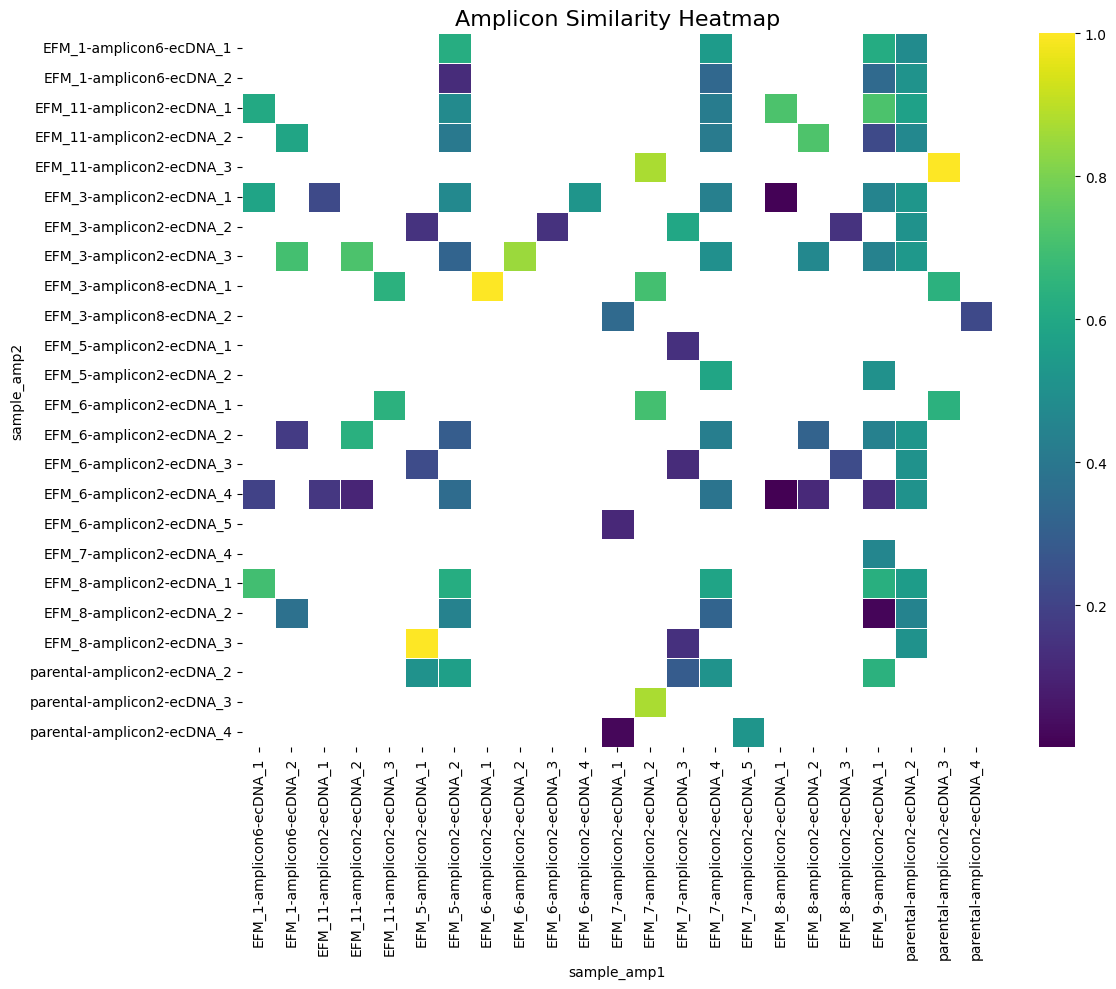

In [23]:
# 1. Pivot table 생성
pivot_df = df_sub.pivot_table(
    index='sample_amp2',      # y-axis
    columns='sample_amp1',    # x-axis
    values='SimilarityScore'
)

# 2. Heatmap 그리기
plt.figure(figsize=(12, 10))

sns.heatmap(
    pivot_df,
    cmap='viridis',   # similarity score에 적합한 colormap
    linewidths=0.5,
    linecolor='white'
)

plt.title('Amplicon Similarity Heatmap', fontsize=16)
plt.xlabel('sample_amp1')
plt.ylabel('sample_amp2')

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [34]:
# pivot_df

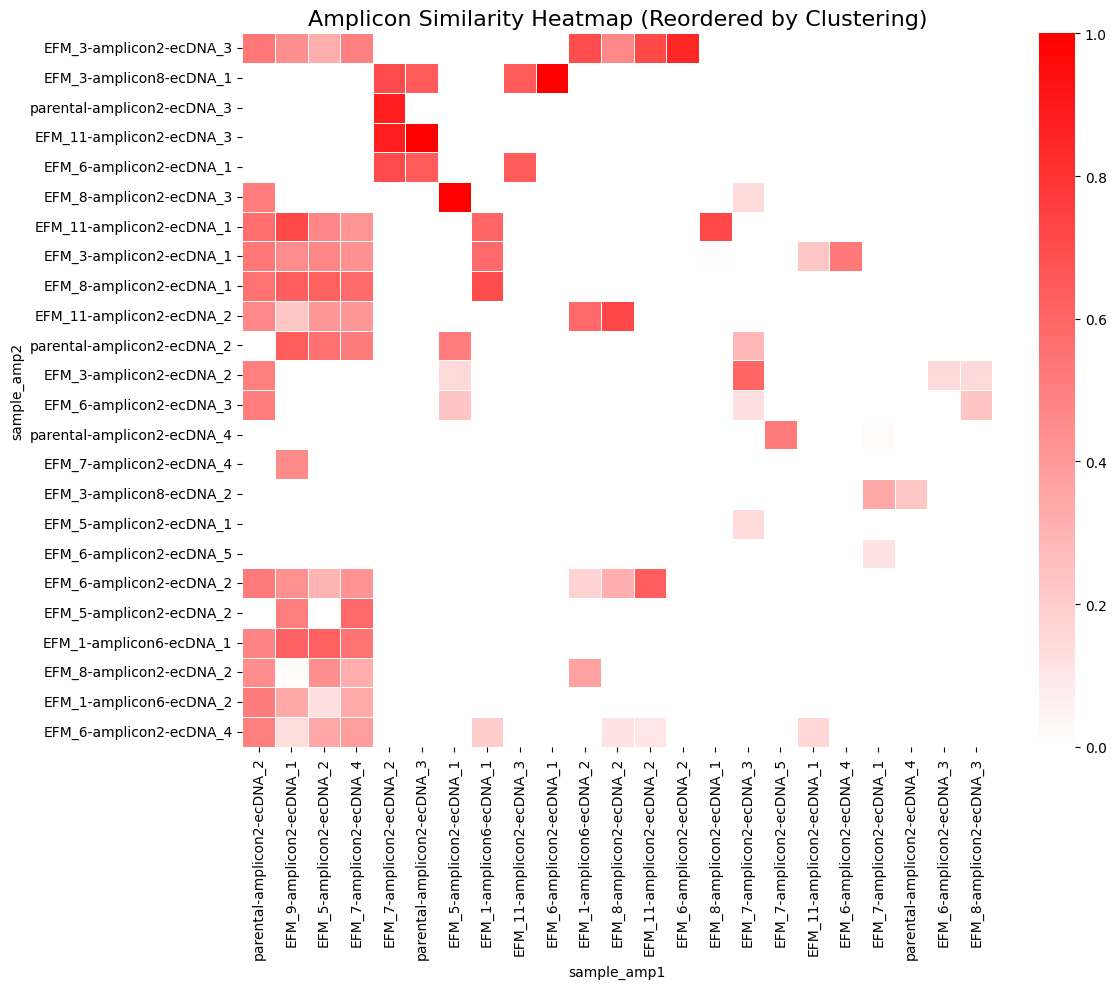

In [28]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# 1. Pivot table
pivot_df = df_sub.pivot_table(
    index='sample_amp2',
    columns='sample_amp1',
    values='SimilarityScore'
)

pivot_df_filled = pivot_df.fillna(0)

# 2. white -> red colormap
white_red = LinearSegmentedColormap.from_list(
    'white_red',
    ['white', 'red']
)

# 3. clustering으로 순서 추출
cg = sns.clustermap(
    pivot_df_filled,
    cmap=white_red,
    vmin=0, vmax=1,
    method='average',
    metric='euclidean',
    figsize=(12, 10)
)

row_order = cg.dendrogram_row.reordered_ind
col_order = cg.dendrogram_col.reordered_ind
plt.close()

# 4. 재정렬 후 다시 heatmap
pivot_sorted = pivot_df_filled.iloc[row_order, col_order]

plt.figure(figsize=(12, 10))
sns.heatmap(
    pivot_sorted,
    cmap=white_red,
    vmin=0, vmax=1,
    linewidths=0.5,
    linecolor='white'
)

plt.title('Amplicon Similarity Heatmap (Reordered by Clustering)', fontsize=16)
plt.xlabel('sample_amp1')
plt.ylabel('sample_amp2')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Source 

In [16]:
# dna_fingerprint_all = pd.read_csv(f'{base_dir}/all/crosscheck_metrics')
dna_fingerprint_source_DM_path = f'{base_dir}/dna_fingerprint/patient/colo320DM.crosscheck_metrics'
# Read the file, skipping the first 6 lines
dna_fingerprint_DM = pd.read_csv(dna_fingerprint_source_DM_path, sep='\t', skiprows=6)

# Display the extracted data
dna_fingerprint_DM.shape

(4, 19)

In [29]:
dna_fingerprint_DM[['LEFT_SAMPLE','RIGHT_SAMPLE','RESULT','LOD_SCORE']]

,LEFT_SAMPLE,RIGHT_SAMPLE,RESULT,LOD_SCORE
0,BIOCHP-SKKUM-0001-TPX-A01,BIOCHP-SKKUM-0001-TPX-A01,EXPECTED_MATCH,7711.572986
1,BIOCHP-SKKUM-0001-TPX-A01,SKKURT-320DM-0001-TPX-A01,EXPECTED_MATCH,4942.901867
2,SKKURT-320DM-0001-TPX-A01,BIOCHP-SKKUM-0001-TPX-A01,EXPECTED_MATCH,4942.901867
3,SKKURT-320DM-0001-TPX-A01,SKKURT-320DM-0001-TPX-A01,EXPECTED_MATCH,12239.665360


In [17]:
# dna_fingerprint_all = pd.read_csv(f'{base_dir}/all/crosscheck_metrics')
dna_fingerprint_source_HSR_path = f'{base_dir}/dna_fingerprint/patient/colo320HSR.crosscheck_metrics'
# Read the file, skipping the first 6 lines
dna_fingerprint_HSR = pd.read_csv(dna_fingerprint_source_HSR_path, sep='\t', skiprows=6)

# Display the extracted data
dna_fingerprint_HSR.shape

(4, 19)

In [28]:
dna_fingerprint_HSR[['LEFT_SAMPLE','RIGHT_SAMPLE','RESULT','LOD_SCORE']]

,LEFT_SAMPLE,RIGHT_SAMPLE,RESULT,LOD_SCORE
0,SKKURT-320HS-0001-TPX-A01,SKKURT-320HS-0001-TPX-A01,EXPECTED_MATCH,12153.252794
1,SKKURT-320HS-0001-TPX-A01,BIOCHP-SKKUM-0002-TPX-A01,EXPECTED_MATCH,1459.984004
2,BIOCHP-SKKUM-0002-TPX-A01,SKKURT-320HS-0001-TPX-A01,EXPECTED_MATCH,1459.984004
3,BIOCHP-SKKUM-0002-TPX-A01,BIOCHP-SKKUM-0002-TPX-A01,EXPECTED_MATCH,2389.833392


# ClusterCrosscheckMetrics_all

In [7]:
dna_fingerprint_clustered_path = f'{base_dir}/dna_fingerprint/ClusterCrosscheckMetrics_all/clustered.crosscheck_metrics'
# Read the file, skipping the first 6 lines
dna_fingerprint_clustered = pd.read_csv(dna_fingerprint_clustered_path, sep='\t', skiprows=6)

# Display the extracted data
dna_fingerprint_clustered.shape
dna_fingerprint_clustered[['CLUSTER', 'CLUSTER_SIZE','LEFT_SAMPLE','RIGHT_SAMPLE','RESULT']]


,CLUSTER,CLUSTER_SIZE,LEFT_SAMPLE,RIGHT_SAMPLE,RESULT
0,0,34,ECTRES-ECGI1-0001-TPX-A26,ECTRES-ECGI1-0001-TPX-A23,UNEXPECTED_MATCH
1,0,34,ECTRES-ECGI1-0001-TPX-A18,ECTRES-ECGI1-0001-TPX-A31,UNEXPECTED_MATCH
2,0,34,ECTRES-ECGI1-0001-TPX-A01,ECTRES-ECGI1-0001-TPX-A11,UNEXPECTED_MATCH
3,0,34,ECTRES-ECGI1-0001-TPX-A08,ECTRES-ECGI1-0001-TPX-A30,UNEXPECTED_MATCH
4,0,34,ECTRES-ECGI1-0001-TPX-A04,ECTRES-ECGI1-0001-TPX-A12,UNEXPECTED_MATCH
...,...,...,...,...,...
2296,34,32,ECTRES-H2170-0001-TPX-A29,ECTRES-H2170-0001-TPX-A30,UNEXPECTED_MATCH
2297,34,32,ECTRES-H2170-0001-TPX-A07,ECTRES-H2170-0001-TPX-A31,UNEXPECTED_MATCH
2298,34,32,ECTRES-H2170-0001-TPX-A19,ECTRES-H2170-0001-TPX-A07,UNEXPECTED_MATCH
2299,34,32,ECTRES-H2170-0001-TPX-A25,ECTRES-H2170-0001-TPX-A02,UNEXPECTED_MATCH


In [8]:
dna_fingerprint_clustered.columns

Index(['CLUSTER', 'CLUSTER_SIZE', 'LEFT_GROUP_VALUE', 'RIGHT_GROUP_VALUE',
       'RESULT', 'DATA_TYPE', 'LOD_SCORE', 'LOD_SCORE_TUMOR_NORMAL',
       'LOD_SCORE_NORMAL_TUMOR', 'LEFT_RUN_BARCODE', 'LEFT_LANE',
       'LEFT_MOLECULAR_BARCODE_SEQUENCE', 'LEFT_LIBRARY', 'LEFT_SAMPLE',
       'LEFT_FILE', 'RIGHT_RUN_BARCODE', 'RIGHT_LANE',
       'RIGHT_MOLECULAR_BARCODE_SEQUENCE', 'RIGHT_LIBRARY', 'RIGHT_SAMPLE',
       'RIGHT_FILE'],
      dtype='object')

In [9]:
dna_fingerprint_clustered

,CLUSTER,CLUSTER_SIZE,LEFT_GROUP_VALUE,RIGHT_GROUP_VALUE,RESULT,DATA_TYPE,LOD_SCORE,LOD_SCORE_TUMOR_NORMAL,LOD_SCORE_NORMAL_TUMOR,LEFT_RUN_BARCODE,...,LEFT_MOLECULAR_BARCODE_SEQUENCE,LEFT_LIBRARY,LEFT_SAMPLE,LEFT_FILE,RIGHT_RUN_BARCODE,RIGHT_LANE,RIGHT_MOLECULAR_BARCODE_SEQUENCE,RIGHT_LIBRARY,RIGHT_SAMPLE,RIGHT_FILE
0,0,34,file:///mnt/storage/tmp/nxf.LHADba43NA/ECTRES-...,file:///mnt/storage/tmp/nxf.LHADba43NA/ECTRES-...,UNEXPECTED_MATCH,FILE,1900.520687,-4022.743367,-4091.598475,2333VCLT4,...,NaN,ZKDN250033017,ECTRES-ECGI1-0001-TPX-A26,file:///mnt/storage/tmp/nxf.LHADba43NA/ECTRES-...,2333VCLT4,7,NaN,ZKDN250033014,ECTRES-ECGI1-0001-TPX-A23,file:///mnt/storage/tmp/nxf.LHADba43NA/ECTRES-...
1,0,34,file:///mnt/storage/tmp/nxf.LHADba43NA/ECTRES-...,file:///mnt/storage/tmp/nxf.LHADba43NA/ECTRES-...,UNEXPECTED_MATCH,FILE,1873.345550,-4123.781855,-4106.375147,2333VCLT4,...,NaN,ZKDN250033009,ECTRES-ECGI1-0001-TPX-A18,file:///mnt/storage/tmp/nxf.LHADba43NA/ECTRES-...,2333VCLT4,7,NaN,ZKDN250033022,ECTRES-ECGI1-0001-TPX-A31,file:///mnt/storage/tmp/nxf.LHADba43NA/ECTRES-...
2,0,34,file:///mnt/storage/tmp/nxf.LHADba43NA/ECTRES-...,file:///mnt/storage/tmp/nxf.LHADba43NA/ECTRES-...,UNEXPECTED_MATCH,FILE,3769.914958,-5356.511531,-4689.576777,22NJLGLT4,...,NaN,DKDN250022574,ECTRES-ECGI1-0001-TPX-A01,file:///mnt/storage/tmp/nxf.LHADba43NA/ECTRES-...,232N3WLT3,8,NaN,ZKDN250033002,ECTRES-ECGI1-0001-TPX-A11,file:///mnt/storage/tmp/nxf.LHADba43NA/ECTRES-...
3,0,34,file:///mnt/storage/tmp/nxf.LHADba43NA/ECTRES-...,file:///mnt/storage/tmp/nxf.LHADba43NA/ECTRES-...,UNEXPECTED_MATCH,FILE,1639.754980,-3693.394107,-3750.827866,2333VCLT4,...,NaN,ZKDN250032999,ECTRES-ECGI1-0001-TPX-A08,file:///mnt/storage/tmp/nxf.LHADba43NA/ECTRES-...,2333VCLT4,7,NaN,ZKDN250033021,ECTRES-ECGI1-0001-TPX-A30,file:///mnt/storage/tmp/nxf.LHADba43NA/ECTRES-...
4,0,34,file:///mnt/storage/tmp/nxf.LHADba43NA/ECTRES-...,file:///mnt/storage/tmp/nxf.LHADba43NA/ECTRES-...,UNEXPECTED_MATCH,FILE,1764.135921,-5935.224129,-5948.427434,<MULTIPLE_VALUES>,...,NaN,ZKDN250032995,ECTRES-ECGI1-0001-TPX-A04,file:///mnt/storage/tmp/nxf.LHADba43NA/ECTRES-...,232N3WLT3,8,NaN,ZKDN250033003,ECTRES-ECGI1-0001-TPX-A12,file:///mnt/storage/tmp/nxf.LHADba43NA/ECTRES-...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2296,34,32,file:///mnt/storage/tmp/nxf.LHADba43NA/ECTRES-...,file:///mnt/storage/tmp/nxf.LHADba43NA/ECTRES-...,UNEXPECTED_MATCH,FILE,1688.546910,-4224.192959,-4408.547366,237Y7NLT3,...,NaN,DKDN260000047,ECTRES-H2170-0001-TPX-A29,file:///mnt/storage/tmp/nxf.LHADba43NA/ECTRES-...,237Y7NLT3,4,NaN,DKDN260000048,ECTRES-H2170-0001-TPX-A30,file:///mnt/storage/tmp/nxf.LHADba43NA/ECTRES-...
2297,34,32,file:///mnt/storage/tmp/nxf.LHADba43NA/ECTRES-...,file:///mnt/storage/tmp/nxf.LHADba43NA/ECTRES-...,UNEXPECTED_MATCH,FILE,1753.841344,-4070.770065,-4312.721250,2333VCLT4,...,NaN,ZKDN250033031,ECTRES-H2170-0001-TPX-A07,file:///mnt/storage/tmp/nxf.LHADba43NA/ECTRES-...,237Y7NLT3,4,NaN,DKDN260000049,ECTRES-H2170-0001-TPX-A31,file:///mnt/storage/tmp/nxf.LHADba43NA/ECTRES-...
2298,34,32,file:///mnt/storage/tmp/nxf.LHADba43NA/ECTRES-...,file:///mnt/storage/tmp/nxf.LHADba43NA/ECTRES-...,UNEXPECTED_MATCH,FILE,1640.921371,-4099.020569,-4288.097477,237Y7NLT3,...,NaN,DKDN260000037,ECTRES-H2170-0001-TPX-A19,file:///mnt/storage/tmp/nxf.LHADba43NA/ECTRES-...,2333VCLT4,8,NaN,ZKDN250033031,ECTRES-H2170-0001-TPX-A07,file:///mnt/storage/tmp/nxf.LHADba43NA/ECTRES-...
2299,34,32,file:///mnt/storage/tmp/nxf.LHADba43NA/ECTRES-...,file:///mnt/storage/tmp/nxf.LHADba43NA/ECTRES-...,UNEXPECTED_MATCH,FILE,1506.423083,-3901.198000,-4056.156947,237Y7NLT3,...,NaN,DKDN260000043,ECTRES-H2170-0001-TPX-A25,file:///mnt/storage/tmp/nxf.LHADba43NA/ECTRES-...,2333VCLT4,7,NaN,ZKDN250033026,ECTRES-H2170-0001-TPX-A02,file:///mnt/storage/tmp/nxf.LHADba43NA/ECTRES-...


In [11]:
df_fp=dna_fingerprint[['LEFT_SAMPLE','RIGHT_SAMPLE','RESULT']]

df_fp['LEFT_SAMPLE'] = df_fp['LEFT_SAMPLE'].apply(assign_tag2)
df_fp['RIGHT_SAMPLE'] = df_fp['RIGHT_SAMPLE'].apply(assign_tag2)

NameError: name 'dna_fingerprint' is not defined

In [10]:
matrix = pd.DataFrame(np.nan, index=order2, columns=order2)
for _, row in df_fp.iterrows():
    left = row['LEFT_SAMPLE']
    right = row['RIGHT_SAMPLE']
    if left in order2 and right in order2:
        val = 1 if row['RESULT'] == 'EXPECTED_MATCH' else 0.99
        matrix.loc[left, right] = val
        matrix.loc[right, left] = val  # 대칭 채움

# 자기 자신은 1
for tag in order2:
    matrix.loc[tag, tag] = 1

# 상삼각 마스크
mask_upper = np.tril(np.ones_like(matrix, dtype=bool), k=-1)  # 왼쪽 아래 삼각형만 표시
# mask_upper = np.triu(np.ones_like(matrix, dtype=bool), k=1)

# 시각화
plt.figure(figsize=(8, 6))
sns.heatmap(matrix, mask=~mask_upper, cmap="Reds", annot=True, fmt=".2f", square=True,
            linewidths=0.5, cbar_kws={'label': 'Match Status'}, vmin=0.99, vmax=1.0)

plt.title("CrosscheckFingerprint Match Heatmap (Lower Triangular, 1=Expected, 0.99=Unexpected)")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

NameError: name 'order2' is not defined